
Dataset Loaded Successfully
   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583

Model Training Completed

Predicted Per Capita Income in 2020:
41288.69

MSE: 15462739.0615
RMSE: 3932.2689
R2 Score: 0.8909
Tolerance Accuracy: 29.79 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


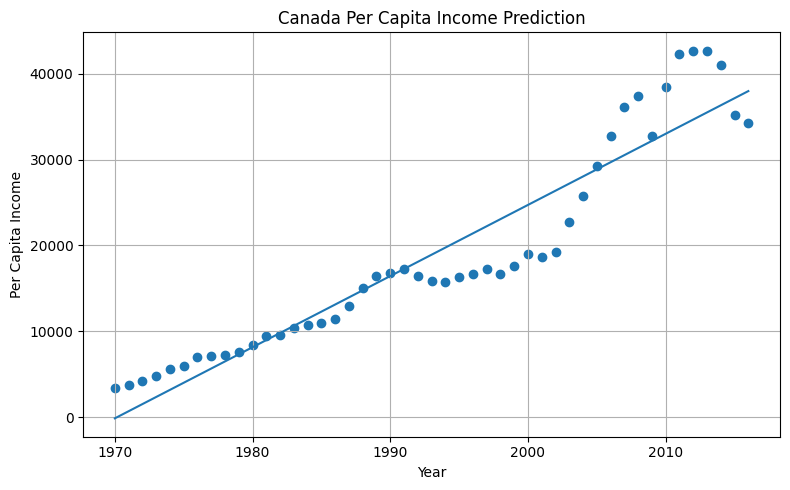


Model Saved Successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv("canada_per_capita_income.csv")

print("\nDataset Loaded Successfully")

print(data.head())

X = data[["year"]]

y = data["per capita income (US$)"]

model = LinearRegression()

model.fit(X, y)

print("\nModel Training Completed")

year_2020 = np.array([[2020]])

prediction = model.predict(year_2020)

print("\nPredicted Per Capita Income in 2020:")

print(round(float(prediction[0]), 2))

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y, y_pred)

print("\nMSE:", round(mse, 4))

print("RMSE:", round(rmse, 4))

print("R2 Score:", round(r2, 4))

tolerance = 1000

correct = np.sum(
    np.abs(y - y_pred) <= tolerance
)

accuracy = correct / len(y)

print("Tolerance Accuracy:", round(accuracy * 100, 2), "%")

plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.plot(X, y_pred)

plt.xlabel("Year")

plt.ylabel("Per Capita Income")

plt.title("Canada Per Capita Income Prediction")

plt.grid(True)

plt.tight_layout()

plt.savefig("canada_income_prediction.png")

plt.show()

joblib.dump(
    model,
    "canada_income_model.pkl"
)

print("\nModel Saved Successfully")